In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
pd.set_option('display.max_columns', None)

In [41]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [42]:
df.shape

(3544, 18)

In [43]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,pareena mi casa,sector 68,1.90,9228.0,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49
1,flat,alpha corp gurgaonone,sector 84,2.28,8769.0,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61
2,flat,m3m sierra 68,sector 68,1.10,8987.0,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127
3,house,ireo victory valley4.0 ?,sector 67,8.00,22222.0,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151
4,flat,kiran residency,sector 56,1.54,8324.0,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98


In [44]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [45]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 68,1.90,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49
1,flat,sector 84,2.28,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61
2,flat,sector 68,1.10,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127
3,house,sector 67,8.00,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151
4,flat,sector 56,1.54,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98


#### **luxury score**

<Axes: xlabel='luxury_score'>

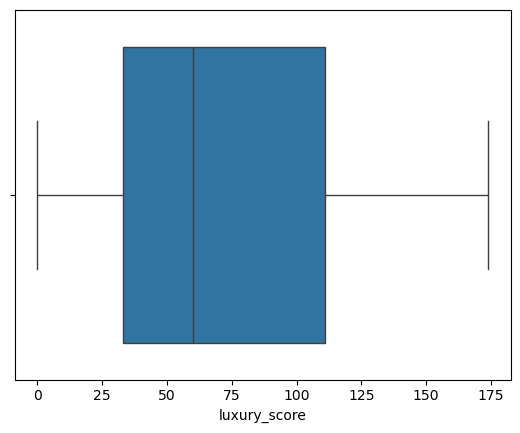

In [46]:
sns.boxplot(x=df['luxury_score'])

In [47]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [48]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [49]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 68,1.90,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49,Low
1,flat,sector 84,2.28,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61,Medium
2,flat,sector 68,1.10,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127,Medium
3,house,sector 67,8.00,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151,High
4,flat,sector 56,1.54,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98,Medium


#### **floorNum**

<Axes: xlabel='floorNum'>

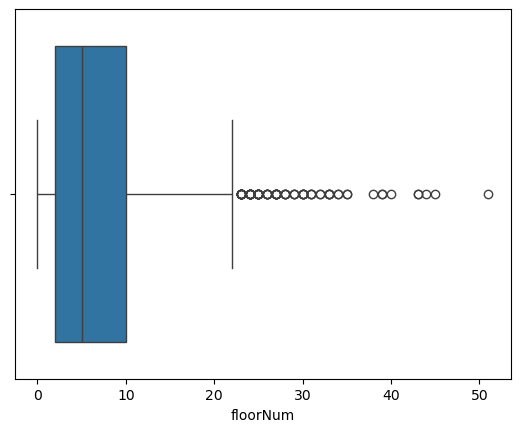

In [50]:
sns.boxplot(x=df['floorNum'])

In [51]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [52]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [53]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 68,1.90,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49,Low,Low Floor
1,flat,sector 84,2.28,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61,Medium,Mid Floor
2,flat,sector 68,1.10,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127,Medium,Low Floor
3,house,sector 67,8.00,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151,High,Mid Floor
4,flat,sector 56,1.54,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98,Medium,Mid Floor


In [54]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [55]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 68,1.90,3,3,3+,Under Construction,2288.0,0,1,0,0,0,0,Low,Low Floor
1,flat,sector 84,2.28,4,4,3+,Relatively New,2998.0,0,1,0,0,0,0,Medium,Mid Floor
2,flat,sector 68,1.10,2,2,3,Relatively New,1150.0,0,0,0,0,0,1,Medium,Low Floor
3,house,sector 67,8.00,6,7,3+,Moderately Old,3600.0,1,1,1,1,0,1,High,Mid Floor
4,flat,sector 56,1.54,3,4,3+,Old Property,1900.0,0,1,0,0,0,0,Medium,Mid Floor


In [56]:
from sklearn.preprocessing import OrdinalEncoder


In [57]:
# create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
x_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sect

In [58]:
x_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,79.0,3,3,4.0,4.0,2288.0,0,1,0,0,0,0,1.0,1.0
1,0.0,98.0,4,4,4.0,3.0,2998.0,0,1,0,0,0,0,2.0,2.0
2,0.0,79.0,2,2,3.0,3.0,1150.0,0,0,0,0,0,1,2.0,1.0
3,1.0,77.0,6,7,4.0,0.0,3600.0,1,1,1,1,0,1,0.0,2.0
4,0.0,65.0,3,4,4.0,2.0,1900.0,0,1,0,0,0,0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3539,1.0,56.0,5,7,3.0,0.0,2727.0,0,1,0,1,0,1,2.0,1.0
3540,1.0,48.0,2,2,4.0,0.0,900.0,0,1,1,0,0,0,1.0,2.0
3541,0.0,103.0,3,3,4.0,1.0,1946.0,0,1,0,0,0,0,1.0,0.0
3542,0.0,27.0,1,2,2.0,0.0,723.0,0,0,0,0,0,0,2.0,2.0


In [59]:
y_label

0       1.90
1       2.28
2       1.10
3       8.00
4       1.54
        ... 
3539    5.15
3540    1.70
3541    1.85
3542    0.56
3543    7.20
Name: price, Length: 3544, dtype: float64

#### **Technique 1 - Correlation Analysis**

<Axes: >

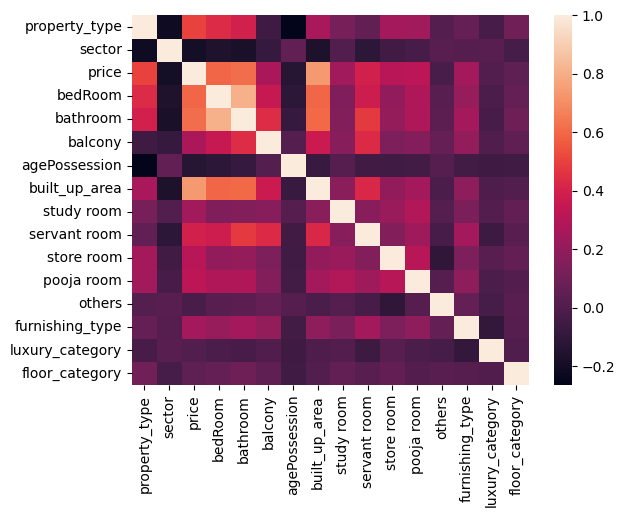

In [60]:
sns.heatmap(data_label_encoded.corr())

In [80]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.200523
1,price,1.000000
2,bedRoom,0.591345
3,bathroom,0.610138
4,balcony,0.270332
5,agePossession,-0.134279
6,built_up_area,0.737475
7,study room,0.242538
8,servant room,0.392299
9,store room,0.311643


#### **Technique 2 - Random Forest Feature Importance**

In [62]:
from sklearn.ensemble import RandomForestRegressor

In [63]:
# Train a Random Forest regressor on Label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(x_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature' : x_label.columns,
    'rf_importance' : rf_label.feature_importances_
}).sort_values(by='rf_importance',ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.642524
0,property_type,0.112173
1,sector,0.102665
3,bathroom,0.024603
2,bedRoom,0.023394
8,servant room,0.023018
5,agePossession,0.015956
4,balcony,0.013213
12,furnishing_type,0.010073
9,store room,0.007614


#### **Technique 3 - Gradient Boosting Feature Importances**

In [64]:
from sklearn.ensemble import GradientBoostingRegressor

In [65]:
# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(x_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature' : x_label.columns,
    'gb_importance' : gb_label.feature_importances_
}).sort_values(by='gb_importance',ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.672036
0,property_type,0.108941
1,sector,0.108406
3,bathroom,0.030646
2,bedRoom,0.029278
8,servant room,0.022101
9,store room,0.015443
5,agePossession,0.004044
12,furnishing_type,0.003247
7,study room,0.002557


#### **Technique 4 - Permutation Importance**

In [66]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [67]:
X_train_label, X_test_label, Y_train_label, Y_test_label = train_test_split(x_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, Y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, Y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': x_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.658990
0,property_type,0.198428
1,sector,0.150017
2,bedRoom,0.030873
3,bathroom,0.012723
8,servant room,0.012662
5,agePossession,0.008588
9,store room,0.004689
7,study room,0.003920
4,balcony,0.003368


#### **Technique 5 - LASSO**

In [68]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

In [69]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled,y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature' : x_label.columns,
    'lasso_coeff':lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.448736
0,property_type,0.751927
3,bathroom,0.270338
9,store room,0.196751
12,furnishing_type,0.175224
7,study room,0.163695
8,servant room,0.159821
10,pooja room,0.073864
13,luxury_category,0.059204
2,bedRoom,0.030527


#### **Technique 6 - RFE**

In [70]:
from sklearn.feature_selection import RFE

In [71]:
# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=x_label.shape[1], step=1)
selector_label = selector_label.fit(x_label, y_label)

# Get the selected features based on RFE
selected_features = x_label.columns[selector_label.support_]

# Extract the coefficient for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature' : selected_features,
    'rfe_score' : selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.640351
0,property_type,0.109341
1,sector,0.105494
3,bathroom,0.026365
2,bedRoom,0.025593
8,servant room,0.020598
5,agePossession,0.014025
4,balcony,0.012284
12,furnishing_type,0.011099
13,luxury_category,0.008315


#### **Technique 7 - Linear Regression Weights**

In [72]:
from sklearn.linear_model import LinearRegression

In [73]:
# Train a linear regression model on the label-encoded and standardized training data
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature' : x_label.columns,
    'reg_coeffs' : lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.451160
0,property_type,0.751639
3,bathroom,0.276950
9,store room,0.201262
12,furnishing_type,0.184607
7,study room,0.171707
8,servant room,0.168991
10,pooja room,0.076839
13,luxury_category,0.070708
2,bedRoom,0.033304


#### **Techinque 8 - SHAP**

In [74]:
# import numpy as np
# import shap
# from sklearn.ensemble import RandomForestRegressor

# # Train model
# rf = RandomForestRegressor(n_estimators=100, random_state=42)
# rf.fit(x_label, y_label)

# # SHAP explainer
# explainer = shap.TreeExplainer(rf)

# # Compute SHAP values
# shap_values = explainer(x_label)   # ✅ new API

# # Feature importance (mean absolute SHAP values)
# shap_sum = np.abs(shap_values.values).mean(axis=0)


In [81]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').set_index('feature')
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
sector,-0.200523,0.102665,0.108406,0.150017,-0.051374,0.105494,-0.060578
bedRoom,0.591345,0.023394,0.029278,0.030873,0.030527,0.025593,0.033304
bathroom,0.610138,0.024603,0.030646,0.012723,0.270338,0.026365,0.276950
balcony,0.270332,0.013213,0.001802,0.003368,-0.034808,0.012284,-0.057521
agePossession,-0.134279,0.015956,0.004044,0.008588,-0.000000,0.014025,0.000151
built_up_area,0.737475,0.642524,0.672036,0.658990,1.448736,0.640351,1.451160
study room,0.242538,0.004890,0.002557,0.003920,0.163695,0.005010,0.171707
servant room,0.392299,0.023018,0.022101,0.012662,0.159821,0.020598,0.168991
store room,0.311643,0.007614,0.015443,0.004689,0.196751,0.008267,0.201262


In [82]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [83]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.734510
sector             0.131117
bedRoom            0.030666
bathroom           0.026504
servant room       0.022024
agePossession      0.011979
store room         0.010116
balcony            0.008621
furnishing_type    0.007646
study room         0.004603
luxury_category    0.003842
floor_category     0.003806
pooja room         0.003009
others             0.001558
dtype: float64

In [84]:
x_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,79.0,3,3,4.0,4.0,2288.0,0,1,0,0,0,0,1.0,1.0
1,0.0,98.0,4,4,4.0,3.0,2998.0,0,1,0,0,0,0,2.0,2.0
2,0.0,79.0,2,2,3.0,3.0,1150.0,0,0,0,0,0,1,2.0,1.0
3,1.0,77.0,6,7,4.0,0.0,3600.0,1,1,1,1,0,1,0.0,2.0
4,0.0,65.0,3,4,4.0,2.0,1900.0,0,1,0,0,0,0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3539,1.0,56.0,5,7,3.0,0.0,2727.0,0,1,0,1,0,1,2.0,1.0
3540,1.0,48.0,2,2,4.0,0.0,900.0,0,1,1,0,0,0,1.0,2.0
3541,0.0,103.0,3,3,4.0,1.0,1946.0,0,1,0,0,0,0,1.0,0.0
3542,0.0,27.0,1,2,2.0,0.0,723.0,0,0,0,0,0,0,2.0,2.0


In [85]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, x_label, y_label, cv=5, scoring='r2')

In [86]:
scores.mean()

0.8143785944553594

In [87]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, x_label.drop(columns=['pooja room' , 'study room' , 'others']), y_label, cv=5, scoring='r2')

In [88]:
scores.mean()

0.8147313375398548

In [89]:
export_df = x_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [90]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [91]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,79.0,3,3,4.0,4.0,2288.0,1,0,0,1.0,1.0,1.90
1,0.0,98.0,4,4,4.0,3.0,2998.0,1,0,0,2.0,2.0,2.28
2,0.0,79.0,2,2,3.0,3.0,1150.0,0,0,1,2.0,1.0,1.10
3,1.0,77.0,6,7,4.0,0.0,3600.0,1,1,1,0.0,2.0,8.00
4,0.0,65.0,3,4,4.0,2.0,1900.0,1,0,0,2.0,2.0,1.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3539,1.0,56.0,5,7,3.0,0.0,2727.0,1,0,1,2.0,1.0,5.15
3540,1.0,48.0,2,2,4.0,0.0,900.0,1,1,0,1.0,2.0,1.70
3541,0.0,103.0,3,3,4.0,1.0,1946.0,1,0,0,1.0,0.0,1.85
3542,0.0,27.0,1,2,2.0,0.0,723.0,0,0,0,2.0,2.0,0.56
